<a href="https://colab.research.google.com/github/gunavathibaskaran170/AI-project-/blob/main/Lung_Cancer_Analysis_using_DecisiontTreeClassifier_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lung Cancer Analysis using  DecisiontTreeClassifier**

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  #insurance homework
import seaborn as sns
df =pd.read_csv("/content/drive/MyDrive/DATASET /survey lung cancer.csv")
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


**Applying the ONEHOTENCODING  for the Gender**

In [45]:
from sklearn.preprocessing  import OneHotEncoder
one= OneHotEncoder(sparse_output=False)
df['GENDER']=one.fit_transform(df[['GENDER']])
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,0.0,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,0.0,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,1.0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,0.0,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,1.0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


<Axes: ylabel='AGE'>

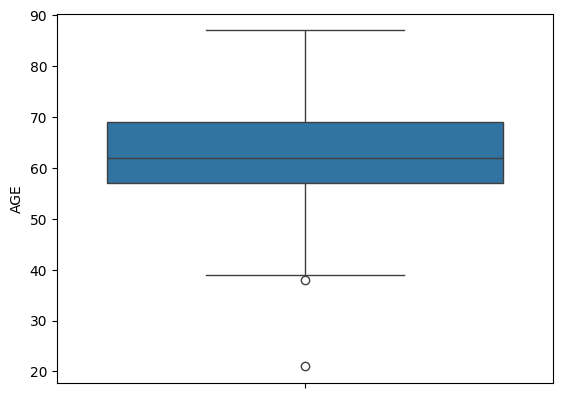

In [46]:
sns.boxplot(df['AGE'])

**Defining the X and Y**

In [47]:

X = df.iloc[:,:-1]
y= df['LUNG_CANCER']
X

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,0.0,69,1,2,2,1,1,2,1,2,2,2,2,2,2
1,0.0,74,2,1,1,1,2,2,2,1,1,1,2,2,2
2,1.0,59,1,1,1,2,1,2,1,2,1,2,2,1,2
3,0.0,63,2,2,2,1,1,1,1,1,2,1,1,2,2
4,1.0,63,1,2,1,1,1,1,1,2,1,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,1.0,56,1,1,1,2,2,2,1,1,2,2,2,2,1
305,0.0,70,2,1,1,1,1,2,2,2,2,2,2,1,2
306,0.0,58,2,1,1,1,1,1,2,2,2,2,1,1,2
307,0.0,67,2,1,2,1,1,2,2,1,2,2,2,1,2


**Handling the outliers**

<Axes: ylabel='AGE'>

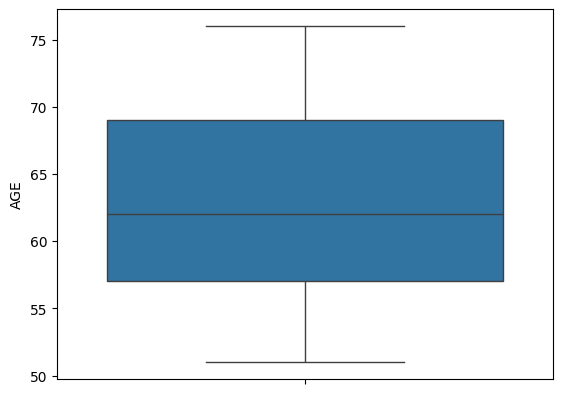

In [48]:
from scipy.stats.mstats import winsorize
df['AGE']=winsorize(df['AGE'],limits=[0.05,0.05])
sns.boxplot(df['AGE'])

**Training the model with Train and Test Data**

In [49]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split (X,y, test_size=0.2,random_state=42)
from sklearn.tree import DecisionTreeClassifier


In [50]:
model= DecisionTreeClassifier(criterion='entropy',max_depth=3) # here we using the entropy it take the smallest values as the Root

In [51]:
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [52]:
y_pred=model.predict(X_test)
y_pred

array(['YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES',
       'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'NO',
       'YES', 'YES', 'NO', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES',
       'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES',
       'YES', 'YES', 'YES', 'YES', 'NO', 'YES', 'YES', 'YES', 'YES',
       'YES', 'YES', 'YES', 'NO', 'YES', 'YES', 'YES', 'YES', 'YES',
       'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES', 'YES'],
      dtype=object)

**Performance Matrix**

In [53]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Classification:",classification_report(y_test,y_pred))

Accuracy: 0.9354838709677419
Classification:               precision    recall  f1-score   support

          NO       0.25      0.50      0.33         2
         YES       0.98      0.95      0.97        60

    accuracy                           0.94        62
   macro avg       0.62      0.72      0.65        62
weighted avg       0.96      0.94      0.95        62



In [54]:
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

Confusion Matrix: [[ 1  1]
 [ 3 57]]


**Displaying the Decision tree**

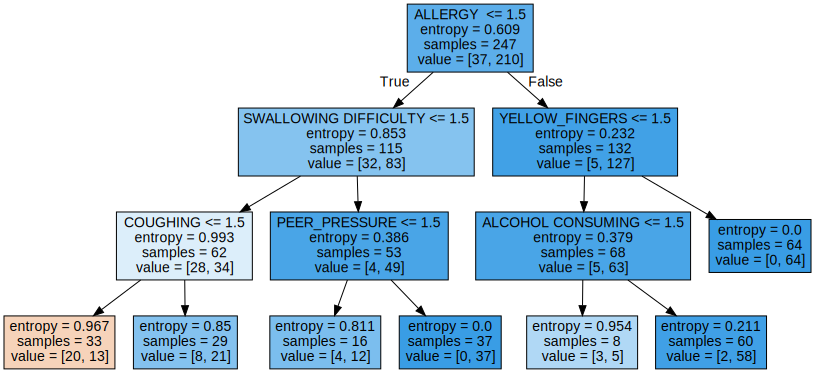

In [55]:
from sklearn.tree import export_graphviz
import graphviz
graphviz.Source(export_graphviz(model,feature_names=X.columns,filled=True))